### After creating the basic measures, we decide to visualize them in a certain way

In [8]:
import pandas as pd
import numpy as np
df = pd.read_csv('overall_patients/overall_measures.csv')
# Select the patient you want 
patient_num = 'P01'
patient_info = df[df.participant_id == patient_num]

In [40]:
table = pd.read_pickle('P08/phases_df.pkl')
table2 = pd.read_pickle('P08/combined_data_with_kinematics.pkl')

## Summary statistics and visualization

### a) Descriptive statistics

In [5]:
# Summary statistics by condition
patient_info.groupby('condition').describe().transpose()


condition                         affected  unaffected
trial_number             count  833.000000  761.000000
                         mean    61.048019   24.844941
                         std     16.413163   16.586048
                         min     21.000000    1.000000
                         25%     49.000000   11.000000
...                                    ...         ...
Range_trunk_displacement min     11.133041    5.682770
                         25%     30.723236   17.535446
                         50%     61.409111   32.136887
                         75%    115.643677   57.286037
                         max    343.982887  168.461670

[712 rows x 2 columns]

### b) Boxplots : used to compare distributions between affected and unaffected sides

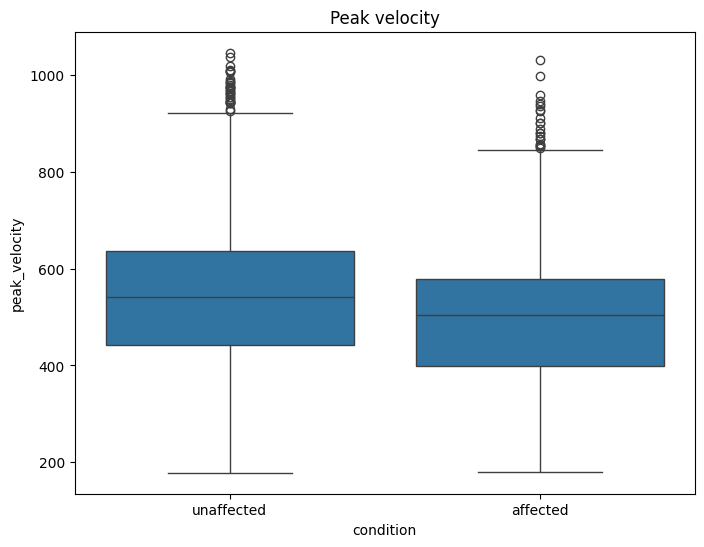

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x = 'condition', y = 'peak_velocity', data = patient_info)
plt.title('Peak velocity')
plt.show()

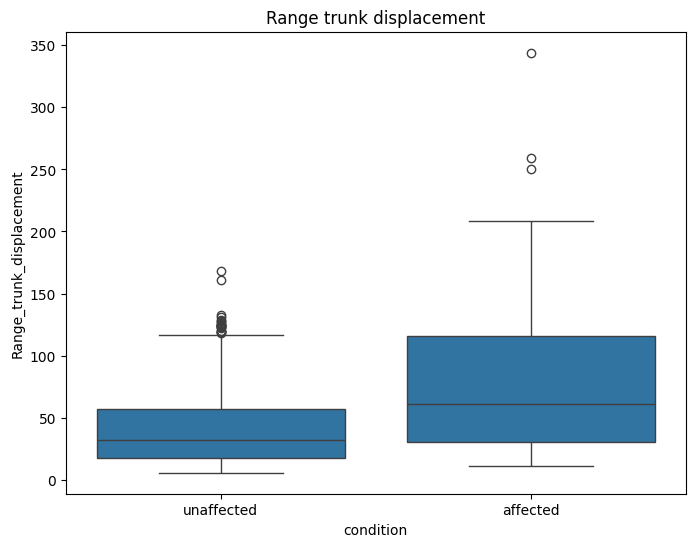

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x = 'condition', y = 'Range_trunk_displacement', data = patient_info)
plt.title('Range trunk displacement')
plt.show()

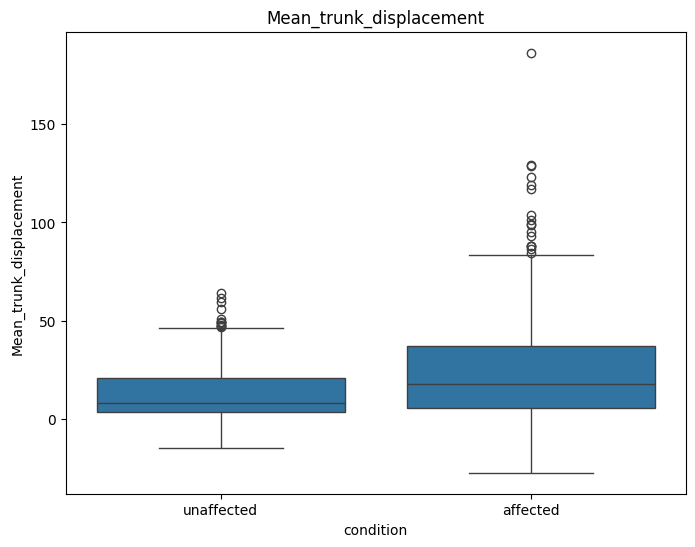

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x = 'condition', y = 'Mean_trunk_displacement', data = patient_info)
plt.title('Mean_trunk_displacement')
plt.show()

### Statistical testing 

#### a) Independent (Unpaired) t-test

In [9]:
from scipy.stats import ttest_ind

# Filter data into affected and unaffected sides for each feature
affected = patient_info.loc[patient_info['condition'] == 'affected', 'peak_velocity']
unaffected = patient_info.loc[patient_info['condition'] == 'unaffected', 'peak_velocity']

# Independent t-test (assumes equal variance) - As the two samples are independent, no requirement for equal sample size
t_stat, p_value = ttest_ind(affected, unaffected, equal_var=True)

print(f'T-statistic: {t_stat:.3f}, p-value: {p_value:.10f}')



T-statistic: -5.967, p-value: 0.0000000030


#### b) Welch’s t-test (more robust version of independent t-test)

This handles unequal sample sizes and unequal variances - More reliable when sample sizes ior variances are different

In [10]:
from scipy.stats import ttest_ind

# Welch’s t-test
t_stat, p_value = ttest_ind(affected, unaffected, equal_var=False)
print(f'T-statistic: {t_stat:.3f}, p-value: {p_value:.10f}')


T-statistic: -5.936, p-value: 0.0000000036


#### c) One sample t-test

In [11]:
from scipy.stats import ttest_1samp

# Test if affected side differs from a known value (e.g., 0)
t_stat, p_value = ttest_1samp(affected, 0)
print(f'T-statistic: {t_stat:.3f}, p-value: {p_value:.35f}')


T-statistic: 102.835, p-value: 0.00000000000000000000000000000000000


### 3. Effect size - As in, how big is the difference in reality

- d < 0.2 → Small effect
- 0.2 ≤ d < 0.5 → Medium effect
- d ≥ 0.5 → Large effect

In [12]:
import numpy as np

d = (np.mean(affected) - np.mean(unaffected)) / np.std(patient_info['peak_velocity'])
print(f"Cohen's d: {d:.3f}")


Cohen's d: -0.296


## Feature importance - Using AI 

### 4. Feature importance using SHAP - to see which features are most influential in determining affected vs unaffected sides  

We could also look into other AI methods

In [9]:
patient_info['condition_label'] = np.where(patient_info.condition == 'affected', 1, 0)
entire = patient_info.sample(frac=1).reset_index(drop=True)


C:\Users\shrinidhi.velan\AppData\Local\Temp\ipykernel_868\1662677517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_info['condition_label'] = np.where(patient_info.condition == 'affected', 1, 0)


In [10]:
X = entire.drop(columns=['participant_id','trial_number','side', 'condition', 'condition_label'])
y = entire.condition_label

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# We use SHAP to see which features are most influential in distinguishing affected vs unaffected sides.


model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

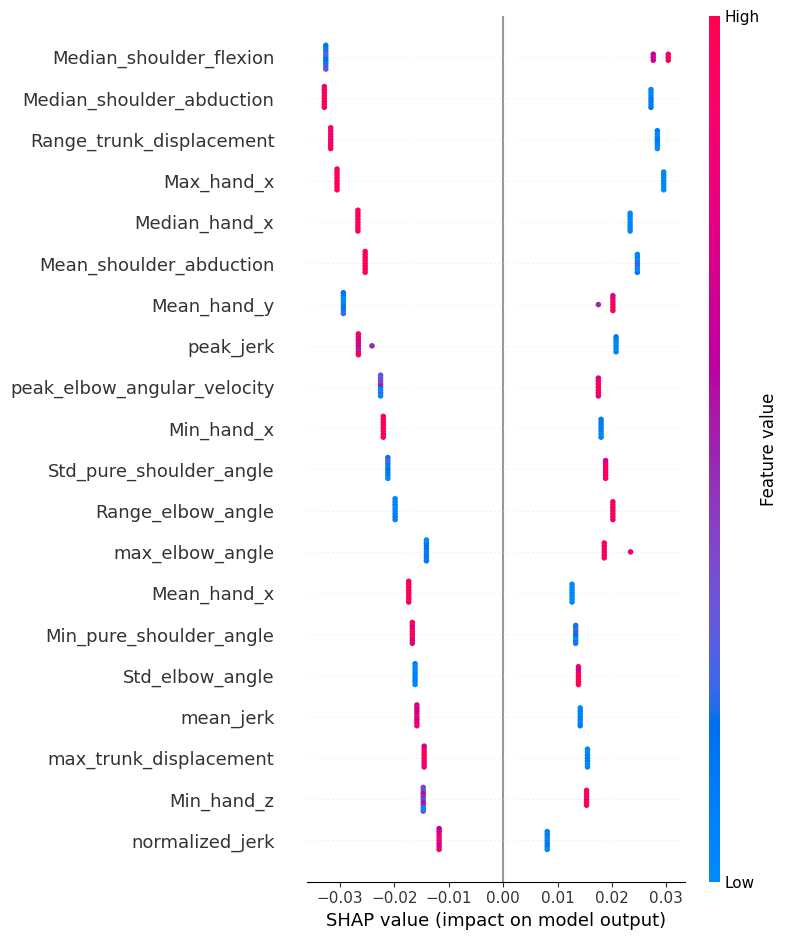

In [18]:
# Now let's apply SHAP
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize feature importance
shap.summary_plot(shap_values[:, :, 0], X_test)  # First class


The previous SHAP summary plot explains how each feature contributes to the model's predictions. 
- 1. THe y-axis defines the feature names : it lists the features ranked by their importance. The features at the top have the most influence on the model's output, while those at the bottom have less influence.
- 2. X-axis (SHAP value) The x-axis shows the SHAP value -- the impact a feature has on the model output. A positive SHAP value means the featzre increases the predicted value, while a negative SHAP value means the feature decreases it.
- 3. Color (Feature value) Each dot represents a single sample. Color gradient shows the actual feature value for that sample : Red (high value) - higher feature values, Blue (low value) - lower feature values
- 4. Spread of points -- Wider spread means that the feature has a more consistent effect. A tighter cluster means the feature has a more consistent effect. 

In [28]:
import joblib

# Save the model
joblib.dump(model, 'model.pkl')



['model.pkl']

In [3]:
import joblib

# Load the model
model = joblib.load('model.pkl')


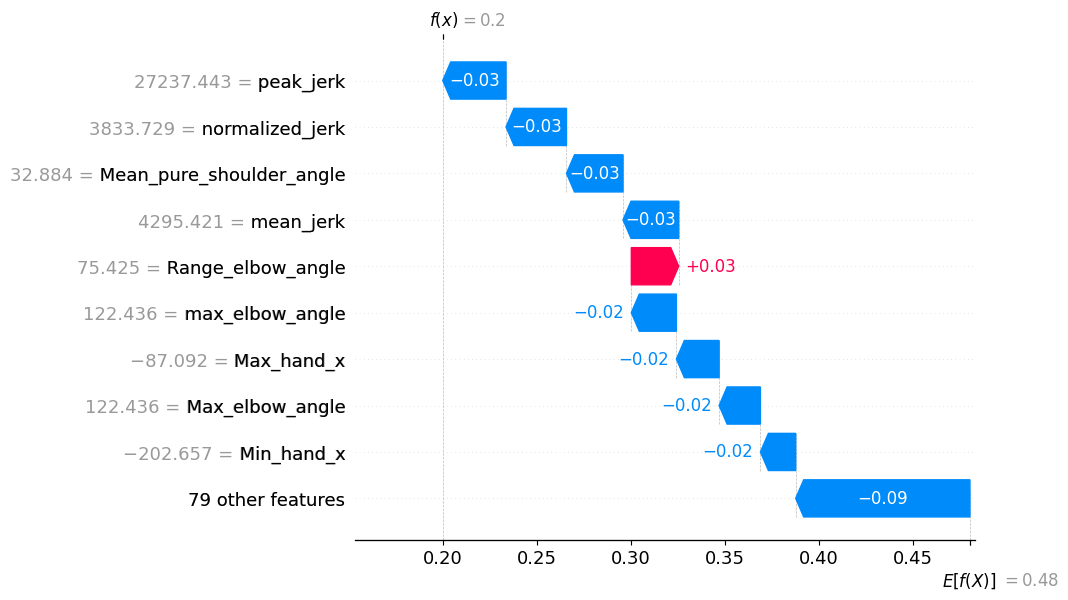

In [32]:
import xgboost as xgb
import shap
import pandas as pd



# SHAP Explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Waterfall plot for the first observation
shap.waterfall_plot(shap_values[0, :, 0])


This is a SHAP waterfall plot — it explains how the model arrived at a specific prediction for a single instance. Here's how to interpret it:

Key Elements:
Base Value (E[f(X)] = 0.48)

This is the model's expected output before seeing any feature values (the average model output across the training set).
In this case, the base value is 0.48.
Final Prediction (f(x) = 0.2)

This is the final model prediction for the specific instance.
The prediction is 0.2, which is lower than the base value — suggesting the model adjusted downward based on feature contributions.
Feature Contributions:

Blue bars → Negative impact on the prediction (pushing it down).
Red bars → Positive impact on the prediction (pushing it up).
The size of each bar reflects the magnitude of the contribution.
Example from the Plot:
peak_jerk = 27237.443 contributes -0.03 → pushing the prediction down.
Range_elbow_angle = 75.425 contributes +0.03 → pushing the prediction up.
Min_hand_x = -202.657 contributes -0.02 → pushing the prediction down.
79 other features combined contribute a total downward pull of -0.09.
Interpretation Summary:
The model’s base prediction was 0.48.
Most features (in blue) pushed the prediction down, especially the combined effect of the 79 other features.
A small number of features (in red) like Range_elbow_angle tried to push the prediction up but were outweighed by the negative contributors.
The final prediction landed at 0.2 due to these combined effects.
This plot helps explain which features and values most influenced the prediction!

In [17]:
print(f"Shape of shap_values: {shap_values.shape}")
print(f"Shape of X_test: {X_test.shape}")


Shape of shap_values: (319, 88, 2)
Shape of X_test: (319, 88)


## Feature importance - for a tree based models such as random forests

In [19]:
importances = model.feature_importances_
features = X_train.columns
sorted(zip(features, importances), key=lambda x: x[1], reverse=True)


[('Median_shoulder_flexion', np.float64(0.06064935064935065)),
 ('Max_hand_x', np.float64(0.06)),
 ('Median_shoulder_abduction', np.float64(0.06)),
 ('Range_trunk_displacement', np.float64(0.06)),
 ('Median_hand_x', np.float64(0.05)),
 ('Mean_shoulder_abduction', np.float64(0.05)),
 ('peak_jerk', np.float64(0.04935483870967742)),
 ('Mean_hand_y', np.float64(0.04205803085803085)),
 ('peak_elbow_angular_velocity', np.float64(0.04)),
 ('Range_elbow_angle', np.float64(0.04)),
 ('Min_hand_x', np.float64(0.04)),
 ('Std_pure_shoulder_angle', np.float64(0.04)),
 ('max_elbow_angle', np.float64(0.03064516129032258)),
 ('max_trunk_displacement', np.float64(0.03)),
 ('mean_jerk', np.float64(0.03)),
 ('Std_elbow_angle', np.float64(0.03)),
 ('Mean_hand_x', np.float64(0.03)),
 ('Min_hand_z', np.float64(0.03)),
 ('Min_pure_shoulder_angle', np.float64(0.03)),
 ('Max_elbow_angle', np.float64(0.02)),
 ('Range_hand_y', np.float64(0.02)),
 ('Range_shoulder_abduction', np.float64(0.02)),
 ('Mean_trunk_displ

## Partial Dependence Plots

c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


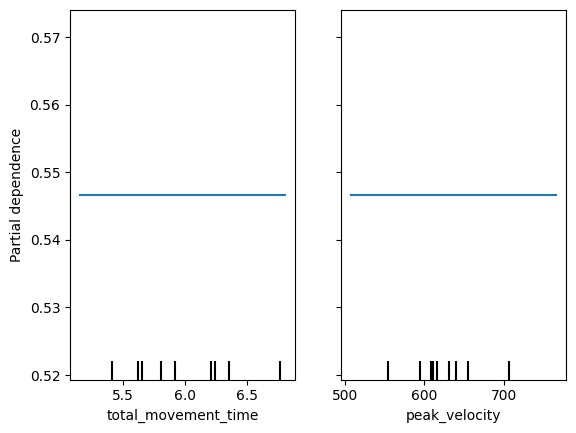

In [21]:
from sklearn.inspection import PartialDependenceDisplay

# Plot partial dependence
PartialDependenceDisplay.from_estimator(model, X_test, [0, 1])

## Anchors - High precision Rule-based explanations

### 5. Correlation between features 
We want to see if certain features are more correlated on the affected side compared to the unaffected side.

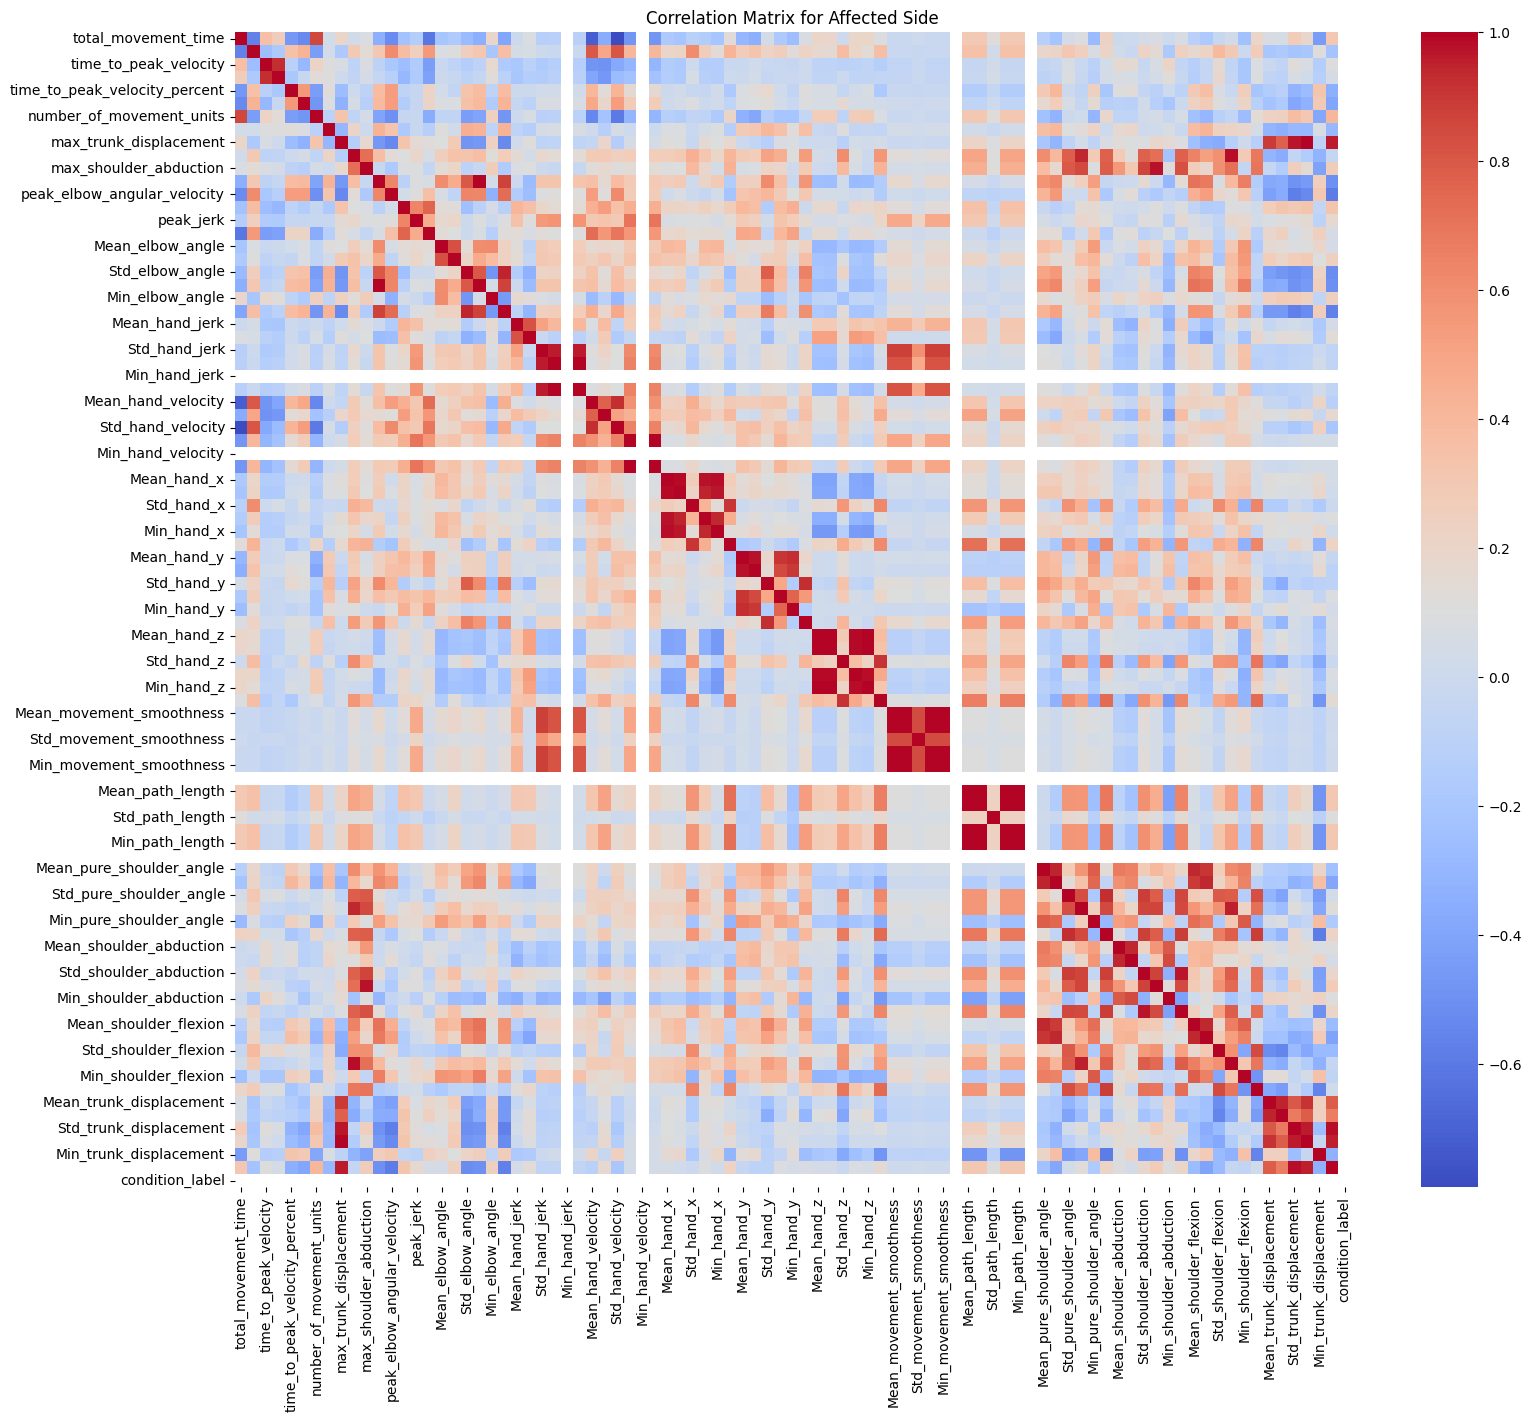

In [18]:

features = entire.drop(columns=['participant_id','trial_number','side', 'condition'])

# Correlation matrix (affected side only)
corr_affected = features.loc[features['condition_label'] == 1].corr()

# Heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_affected, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Correlation Matrix for Affected Side')
plt.show()


For your study on stroke-affected patients, where we are analyzing various features extracted from trials (e.g., peak velocity, trunk displacement), explainable AI (XAI) methods can help toyou interpret the model's decisions and identify which factors are most influential for the outcomes.

### 6. Explainable AI method -- 
- LIME (Local Interpretable Model agnostic Explanations) : Overview: LIME is a model-agnostic method that explains the predictions of any classifier by approximating the model with a simpler, interpretable model (e.g., linear regression, decision tree) locally around the instance being explained.
- Application: For each individual prediction, LIME can help you understand which features (e.g., peak velocity, trunk displacement) contributed most to the predicted outcome (e.g., upper limb function) by showing the relative importance of each feature in the local context.
- Use Case: If you want to explain why a specific patient's trial resulted in a particular prediction, LIME will break down the features influencing that prediction.

In [27]:
from lime import lime_tabular
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import webbrowser

# First, ensure your data is properly prepared
# Assuming you have X (features) and y (target)
# Split your data if not already done
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the LIME explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    mode="classification",
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1'],  # Replace with your actual class names
    discretize_continuous=True
)

# Generate explanation for a specific instance
instance_idx = 0  # Change this to the instance you want to explain
exp = explainer.explain_instance(
    X_test.iloc[instance_idx].values,
    model.predict_proba,
    num_features=10  # Number of features to show in explanation
)

# Generate HTML explanation
html = exp.as_html()

# Save to a file with timestamp to avoid overwriting
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'lime_explanation_{timestamp}.html'

# Save the HTML file
with open(filename, 'w', encoding='utf-8') as f:
    f.write(html)

# Open in default browser
webbrowser.open(filename)

# Optional: Print some additional information
print(f"Explanation saved to: {filename}")
print(f"Instance being explained: {instance_idx}")
print(f"True label: {y_test.iloc[instance_idx]}")
print(f"Predicted probability: {model.predict_proba(X_test.iloc[instance_idx:instance_idx+1])[0]}")

c:\Users\shrinidhi.velan\AppData\Local\anaconda\envs\AutoMQ\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Explanation saved to: lime_explanation_20250319_155049.html
Instance being explained: 0
True label: 0
Predicted probability: [1. 0.]


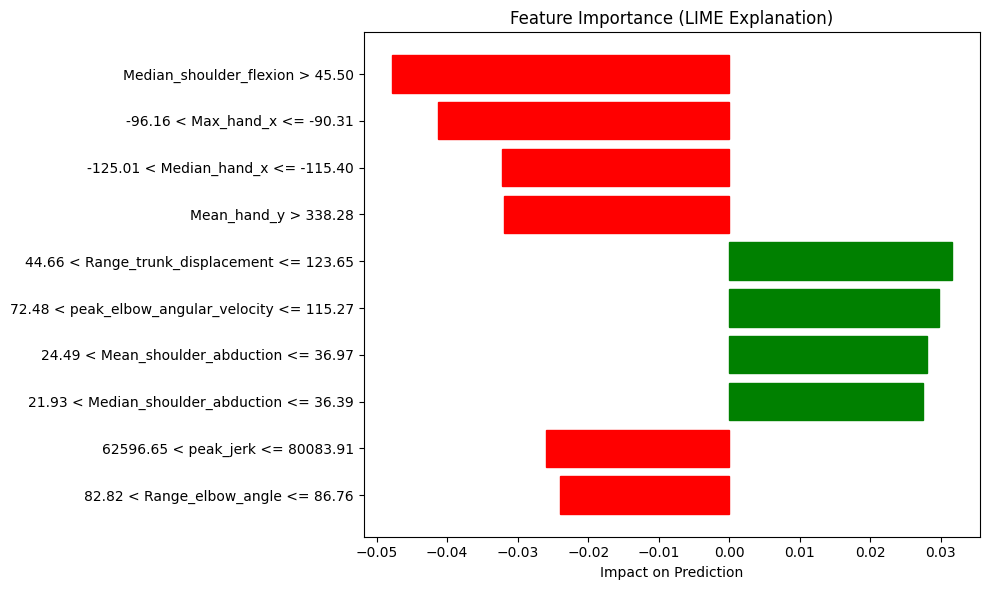


Detailed Feature Impact:
Median_shoulder_flexion > 45.50: -0.0478
-96.16 < Max_hand_x <= -90.31: -0.0414
-125.01 < Median_hand_x <= -115.40: -0.0322
Mean_hand_y > 338.28: -0.0319
44.66 < Range_trunk_displacement <= 123.65: 0.0316
72.48 < peak_elbow_angular_velocity <= 115.27: 0.0298
24.49 < Mean_shoulder_abduction <= 36.97: 0.0280
21.93 < Median_shoulder_abduction <= 36.39: 0.0274
62596.65 < peak_jerk <= 80083.91: -0.0259
82.82 < Range_elbow_angle <= 86.76: -0.0240

Prediction Probabilities: [1. 0.]


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lime import lime_tabular
import plotly.graph_objects as go
import plotly.express as px

# 1. Basic LIME Plot
def plot_lime_explanation(exp):
    """Plot the LIME explanation as a bar chart"""
    plt.figure(figsize=(10, 6))
    exp_list = exp.as_list()
    features = [x[0] for x in exp_list]
    values = [x[1] for x in exp_list]
    
    # Sort by absolute values
    sorted_idx = np.argsort(np.abs(values))
    features = [features[i] for i in sorted_idx]
    values = [values[i] for i in sorted_idx]
    
    # Create bar plot
    bars = plt.barh(range(len(features)), values)
    
    # Color bars based on positive/negative values
    for i, bar in enumerate(bars):
        if values[i] >= 0:
            bar.set_color('green')
        else:
            bar.set_color('red')
    
    plt.yticks(range(len(features)), features)
    plt.title('Feature Importance (LIME Explanation)')
    plt.xlabel('Impact on Prediction')
    plt.tight_layout()
    plt.show()

# 2. Interactive Plotly Visualization
def plot_lime_interactive(exp):
    """Create an interactive visualization using Plotly"""
    exp_list = exp.as_list()
    features = [x[0] for x in exp_list]
    values = [x[1] for x in exp_list]
    
    # Sort by absolute values
    sorted_idx = np.argsort(np.abs(values))
    features = [features[i] for i in sorted_idx]
    values = [values[i] for i in sorted_idx]
    
    fig = go.Figure()
    
    # Add bars
    fig.add_trace(go.Bar(
        y=features,
        x=values,
        orientation='h',
        marker_color=['red' if v < 0 else 'green' for v in values],
        name='Feature Impact'
    ))
    
    fig.update_layout(
        title='Interactive Feature Importance (LIME)',
        xaxis_title='Impact on Prediction',
        yaxis_title='Features',
        showlegend=False,
        height=max(400, len(features) * 25)
    )
    
    fig.show()



# Usage example:
# Generate all visualizations
plot_lime_explanation(exp)
plot_lime_interactive(exp)

# Additional information
print("\nDetailed Feature Impact:")
for feature, impact in exp.as_list():
    print(f"{feature}: {impact:.4f}")

# Print prediction confidence
pred_proba = model.predict_proba(X_test.iloc[instance_idx:instance_idx+1])[0]
print(f"\nPrediction Probabilities: {pred_proba}")

### Feature importance with Tree-based models 